In [5]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 연관분석 라이브러리
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import itertools

In [6]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [7]:
df = pd.read_csv("df_merged.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


In [8]:
df = df.dropna()

In [9]:
# Cell 4: User-Item 행렬 구성 (연령대별)
# ===================================================
# 연령대별로 사용자-아이템 이진 구매 행렬 구성
# 행(rows): 사용자, 열(columns): ItemSmallName 카테고리(58개)
# 값: 1(구매함) 또는 0(미구매)

from sklearn.metrics.pairwise import cosine_similarity

age_groups = sorted(df['AgeGroup'].unique())

# 연령대별 행렬을 dict에 저장
ui_matrices = {}  # key: age_group -> pd.DataFrame (users x items, binary)

for age in age_groups:
    group_df = df[df['AgeGroup'] == age]
    
    # Pivot: 구매 횟수, 이진화
    matrix = (
        group_df.groupby(['idUser', 'ItemSmallName'])
        .size()
        .unstack(fill_value=0)
    )
    # 이진화: 1회 이상 구매 = 1, 미구매 = 0
    matrix = (matrix > 0).astype(int)
    
    ui_matrices[age] = matrix
    print(f"[AgeGroup {age}] Users: {matrix.shape[0]:4d} | Items: {matrix.shape[1]:2d} | "
          f"Sparsity: {1 - matrix.values.mean():.2%}")

print(f"\n전체 아이템 카테고리:")
all_items = sorted(set().union(*[m.columns.tolist() for m in ui_matrices.values()]))
print(f"  {len(all_items)}개 고유 아이템")

[AgeGroup 20] Users:  820 | Items: 58 | Sparsity: 11.04%
[AgeGroup 30] Users: 1280 | Items: 58 | Sparsity: 11.15%
[AgeGroup 40] Users:  477 | Items: 58 | Sparsity: 10.63%
[AgeGroup 50] Users:  291 | Items: 58 | Sparsity: 10.73%
[AgeGroup 60] Users:  132 | Items: 58 | Sparsity: 10.93%

전체 아이템 카테고리:
  58개 고유 아이템


In [10]:
# Cell 5: 사용자-사용자 Cosine 유사도 계산
# ==================================================
# 연령대별로 전체 cosine similarity 행렬 계산
# sklearn cosine_similarity는 L2 정규화를 자동 처리

sim_matrices = {}  # key: age_group -> np.ndarray

for age in age_groups:
    matrix = ui_matrices[age]
    sim = cosine_similarity(matrix.values)  # shape: (n_users, n_users)
    sim_matrices[age] = sim
    
    # 통계: 대각선 제거(자기 유사도)
    np.fill_diagonal(sim, 0)
    mean_sim = sim.mean()
    max_sim = sim.max()
    print(f"[AgeGroup {age}] Sim matrix: {sim.shape} | "
          f"Mean similarity: {mean_sim:.4f} | Max: {max_sim:.4f}")

print("\n유사도 행렬 준비 완료.")

[AgeGroup 20] Sim matrix: (820, 820) | Mean similarity: 0.9143 | Max: 1.0000
[AgeGroup 30] Sim matrix: (1280, 1280) | Mean similarity: 0.9133 | Max: 1.0000
[AgeGroup 40] Sim matrix: (477, 477) | Mean similarity: 0.9172 | Max: 1.0000
[AgeGroup 50] Sim matrix: (291, 291) | Mean similarity: 0.9142 | Max: 1.0000
[AgeGroup 60] Sim matrix: (132, 132) | Mean similarity: 0.9054 | Max: 1.0000

유사도 행렬 준비 완료.


In [11]:
# Cell 6: 협업필터링 추천 함수
# ========================================================
# 주어진 사용자에 대해 유사한 사용자들을 찾고, 
# 그들이 구매했지만 대상 사용자가 구매하지 않은 아이템을 추천

def recommend_for_user(user_id, age_group, top_k=10, top_n=5):
    """
    협업필터링: 특정 사용자에게 Top-N 추천 아이템 생성

    Parameters
    ----------
    user_id   : str   — 대상 사용자 ID (예: 'U10001')
    age_group : int   — 연령대 (20, 30, 40, 50, 60)
    top_k     : int   — 고려할 유사 사용자 수 (기본값: 10)
    top_n     : int   — 추천할 아이템 수 (기본값: 5)

    Returns
    -------
    pd.Series  — 추천 아이템 (인덱스: ItemSmallName, 값: 추천 점수)
    """
    matrix = ui_matrices[age_group]          # (n_users x n_items) DataFrame
    sim    = sim_matrices[age_group]         # (n_users x n_users) ndarray, 대각선=0

    if user_id not in matrix.index:
        return pd.Series(dtype=float)

    user_idx = matrix.index.get_loc(user_id)
    user_vec = matrix.iloc[user_idx].values  # 이진 구매 벡터

    # Top-K 유사 사용자 추출 (자기 자신은 대각선=0으로 제외)
    sim_scores = sim[user_idx]
    top_k_idx  = np.argsort(sim_scores)[::-1][:top_k]
    top_k_sims = sim_scores[top_k_idx]

    # Edge case: 모든 유사도가 0인 경우
    if top_k_sims.sum() == 0:
        return pd.Series(dtype=float)

    # 유사 사용자들의 가중 평균 구매 벡터
    neighbor_matrix = matrix.values[top_k_idx]          # (top_k x n_items)
    weights         = top_k_sims.reshape(-1, 1)          # (top_k x 1)
    weighted_scores = (neighbor_matrix * weights).sum(axis=0) / weights.sum()

    # 이미 구매한 아이템은 점수를 0으로 설정
    scores = pd.Series(weighted_scores, index=matrix.columns)
    scores[user_vec.astype(bool)] = 0.0

    return scores.nlargest(top_n)


# 단일 사용자에 대한 추천 테스트
sample_user = ui_matrices[30].index[0]
sample_recs = recommend_for_user(sample_user, age_group=30, top_k=10, top_n=5)
print(f"샘플 추천 (사용자 {sample_user}, 연령대 30대):")
print(sample_recs.to_string())

샘플 추천 (사용자 U10003, 연령대 30대):
ItemSmallName
멸치      0.800291
돼지고기    0.700452
땅콩      0.598533
탄산음료    0.598358
북어      0.500887


In [12]:
# Cell 7: 연령대별 전체 사용자 추천 적용 및 결과 집계
# =============================================================
# 연령대별로 모든 사용자에게 추천을 생성한 후,
# 아이템별 점수를 합산하여 그룹 전체 추천 순위 계산

TOP_K = 10   # 고려할 유사 사용자 수
TOP_N = 5    # 사용자별 추천 아이템 수

age_group_recommendations = {}  # key: age -> pd.Series (item -> 총 점수)

for age in age_groups:
    matrix = ui_matrices[age]
    all_users = matrix.index.tolist()
    
    # 모든 사용자의 추천 점수를 누적
    agg_scores = pd.Series(0.0, index=matrix.columns)
    valid_users = 0
    
    for user_id in all_users:
        recs = recommend_for_user(user_id, age_group=age, top_k=TOP_K, top_n=TOP_N)
        if len(recs) > 0:
            agg_scores = agg_scores.add(recs, fill_value=0)
            valid_users += 1
    
    age_group_recommendations[age] = agg_scores.sort_values(ascending=False)
    
    print(f"\n{'='*55}")
    print(f"  연령대 {age}대 | {valid_users}/{len(all_users)} 명이 추천을 받음")
    print(f"{'='*55}")
    print(f"  Top 10 추천 아이템 (누적 점수):")
    top10 = age_group_recommendations[age].head(10)
    for rank, (item, score) in enumerate(top10.items(), 1):
        print(f"  {rank:2d}. {item:<12s}  점수: {score:8.3f}")

print("\n[완료] 추천 집계 작업 종료")


  연령대 20대 | 820/820 명이 추천을 받음
  Top 10 추천 아이템 (누적 점수):
   1. 땅콩            점수:   94.609
   2. 마른안주          점수:   92.537
   3. 당면            점수:   89.872
   4. 생수            점수:   86.796
   5. 닭고기           점수:   85.628
   6. 조기            점수:   84.481
   7. 북어            점수:   83.915
   8. 파스타           점수:   83.017
   9. 조미료           점수:   80.331
  10. 탄산음료          점수:   78.721

  연령대 30대 | 1280/1280 명이 추천을 받음
  Top 10 추천 아이템 (누적 점수):
   1. 파스타           점수:  132.189
   2. 북어            점수:  129.201
   3. 땅콩            점수:  127.781
   4. 생수            점수:  125.756
   5. 닭고기           점수:  123.503
   6. 아몬드           점수:  120.023
   7. 마른안주          점수:  119.575
   8. 당면            점수:  117.844
   9. 계란            점수:  115.512
  10. 조미료           점수:  114.849

  연령대 40대 | 477/477 명이 추천을 받음
  Top 10 추천 아이템 (누적 점수):
   1. 땅콩            점수:   58.549
   2. 당면            점수:   57.432
   3. 조미료           점수:   57.342
   4. 계란            점수:   56.350
   5. 북어            점수:   55.357
   6.

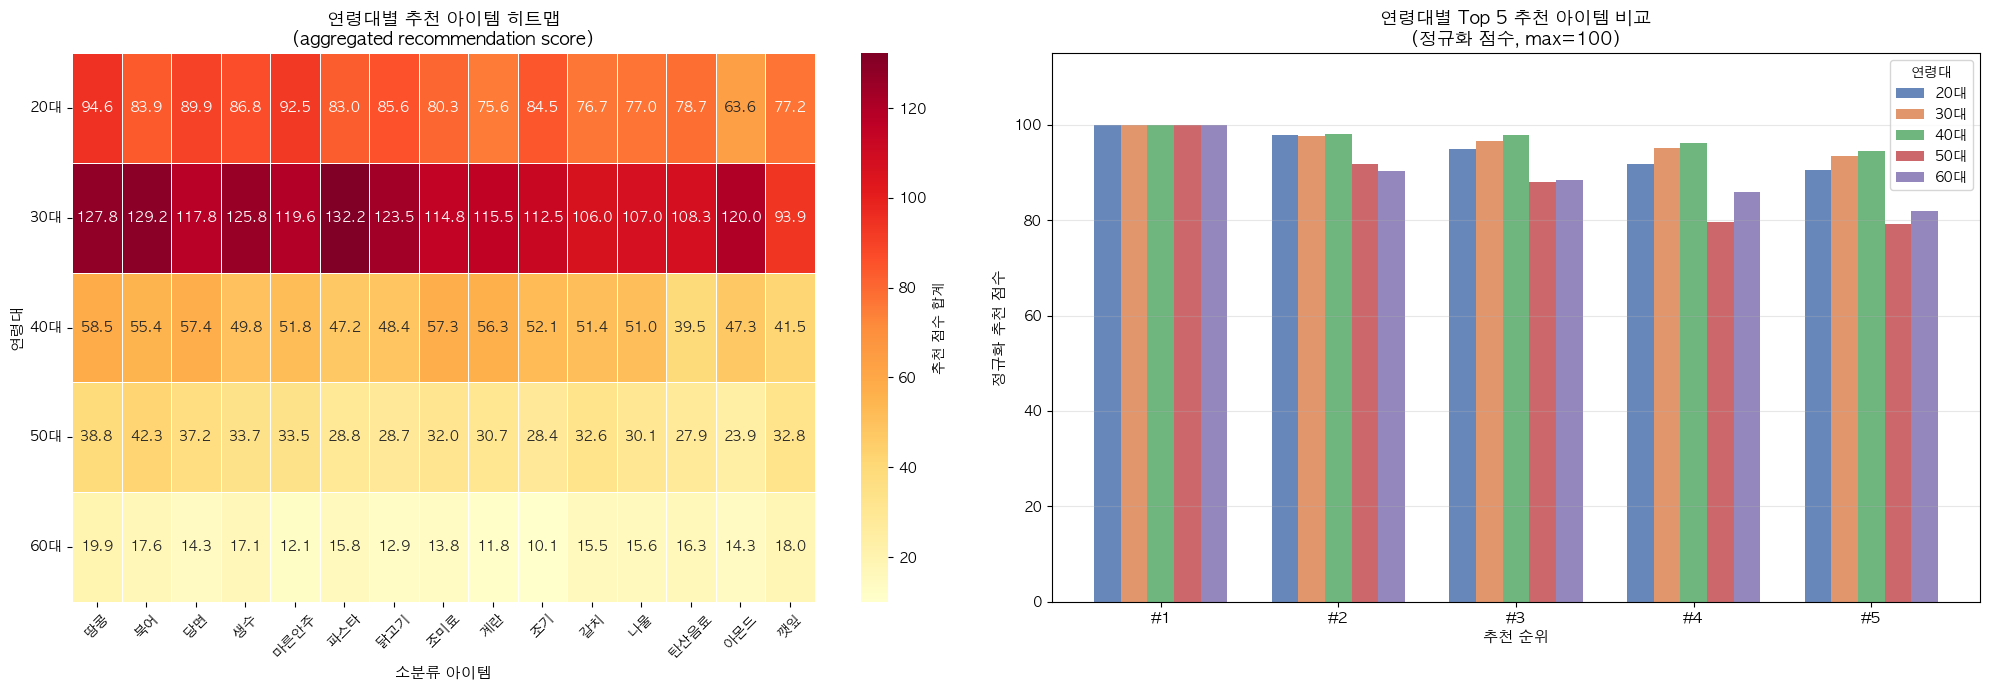

차트 저장: age_group_collaborative_filtering.png


In [13]:
# Cell 8: 시각화 - 연령대별 추천 아이템
# ============================================================
# 히트맵: 연령대(행) × Top-15 아이템(열), 추천 점수 색상
# 막대 차트: 연령대별 Top-5 아이템 비교 (정규화)

# --- 8-1: 히트맵 ---
top_n_viz = 15
# 모든 그룹 통합하여 top-15 아이템 추출
all_agg = pd.concat(age_group_recommendations.values()).groupby(level=0).sum()
top_items_global = all_agg.nlargest(top_n_viz).index.tolist()

heatmap_df = pd.DataFrame(
    {age: age_group_recommendations[age].reindex(top_items_global, fill_value=0)
     for age in age_groups}
).T  # shape: (5 age groups x top_n_viz items)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.heatmap(
    heatmap_df,
    ax=axes[0],
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': '추천 점수 합계'}
)
axes[0].set_title('연령대별 추천 아이템 히트맵\n(aggregated recommendation score)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('소분류 아이템', fontsize=11)
axes[0].set_ylabel('연령대', fontsize=11)
axes[0].set_yticklabels([f'{age}대' for age in age_groups], rotation=0)
axes[0].tick_params(axis='x', rotation=45)

# --- 8-2: 그룹별 막대 차트 (top-5 per age group) ---
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
top5_per_group = {age: age_group_recommendations[age].head(5) for age in age_groups}

# 각 그룹 내에서 정규화 (max=100)
for age in age_groups:
    s = top5_per_group[age]
    max_s = s.max()
    top5_per_group[age] = (s / max_s * 100) if max_s > 0 else s

x_pos = np.arange(5)
bar_width = 0.15
offsets = np.linspace(-(len(age_groups)-1)/2, (len(age_groups)-1)/2, len(age_groups)) * bar_width

for i, (age, color) in enumerate(zip(age_groups, colors)):
    items  = top5_per_group[age].index.tolist()
    scores = top5_per_group[age].values
    bars = axes[1].bar(x_pos + offsets[i], scores, width=bar_width,
                       label=f'{age}대', color=color, alpha=0.85)

axes[1].set_title('연령대별 Top 5 추천 아이템 비교\n(정규화 점수, max=100)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('추천 순위', fontsize=11)
axes[1].set_ylabel('정규화 추천 점수', fontsize=11)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'#{i+1}' for i in range(5)], fontsize=11)
axes[1].legend(title='연령대', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 115)

plt.tight_layout()
plt.savefig('age_group_collaborative_filtering.png', dpi=150, bbox_inches='tight')
plt.show()
print("차트 저장: age_group_collaborative_filtering.png")

In [14]:
# Cell 9: 요약 인사이트
# ========================
# 협업필터링 분석 결과의 주요 발견사항 및 인사이트 출력

print('=' * 70)
print('  연령대별 협업필터링 (User-User Collaborative Filtering) 요약')
print('=' * 70)

print(f'\n[모델 설정]')
print(f'  - 알고리즘  : User-User Cosine Similarity CF')
print(f'  - 유사 사용자: Top-{TOP_K}명 기준 가중 평균 추천')
print(f'  - 사용자 수 : {df["idUser"].nunique():,}명')
print(f'  - 아이템 수 : {df["ItemSmallName"].nunique()}개 (소분류)')

print(f'\n[연령대별 추천 결과 Top 5]')
print('-' * 70)

# 깔끔한 요약 테이블 생성
summary_rows = []
for age in age_groups:
    top5 = age_group_recommendations[age].head(5)
    n_users = ui_matrices[age].shape[0]
    row = {
        '연령대': f'{age}대',
        '사용자수': n_users,
        '1위': top5.index[0] if len(top5) > 0 else '-',
        '2위': top5.index[1] if len(top5) > 1 else '-',
        '3위': top5.index[2] if len(top5) > 2 else '-',
        '4위': top5.index[3] if len(top5) > 3 else '-',
        '5위': top5.index[4] if len(top5) > 4 else '-',
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('연령대')
print(summary_df.to_string())

# 연령대 간 추천 차별성 분석
print(f'\n[연령대 간 추천 차별성 분석]')
print('-' * 70)
for age in age_groups:
    top5_items = set(age_group_recommendations[age].head(5).index)
    other_items = set().union(*[
        set(age_group_recommendations[a].head(5).index)
        for a in age_groups if a != age
    ])
    unique_to_age = top5_items - other_items
    print(f'  {age}대: Top5 중 고유 추천 = {len(unique_to_age)}개', end='')
    if unique_to_age:
        print(f' {list(unique_to_age)}')
    else:
        print(' (없음)')

print(f'\n[주요 인사이트]')
print('-' * 70)

# 연령대별 주요 추천 아이템 요약
for age in age_groups:
    top1 = age_group_recommendations[age].index[0]
    top3 = age_group_recommendations[age].head(3).index.tolist()
    print(f'  {age}대: 가장 많이 추천된 미구매 아이템 → {", ".join(top3)}')

print(f'\n  → 연령대별 선호도 차이를 반영한 개인화 추천이 가능함을 확인')
print(f'  → 협업필터링 기반 Cross-sell 전략으로 활용 가능')
print('=' * 70)

  연령대별 협업필터링 (User-User Collaborative Filtering) 요약

[모델 설정]
  - 알고리즘  : User-User Cosine Similarity CF
  - 유사 사용자: Top-10명 기준 가중 평균 추천
  - 사용자 수 : 3,000명
  - 아이템 수 : 58개 (소분류)

[연령대별 추천 결과 Top 5]
----------------------------------------------------------------------
     사용자수   1위    2위   3위  4위    5위
연령대                                
20대   820   땅콩  마른안주   당면  생수   닭고기
30대  1280  파스타    북어   땅콩  생수   닭고기
40대   477   땅콩    당면  조미료  계란    북어
50대   291   북어    땅콩   당면  생수  마른안주
60대   132   땅콩    깻잎   북어  생수  탄산음료

[연령대 간 추천 차별성 분석]
----------------------------------------------------------------------
  20대: Top5 중 고유 추천 = 0개 (없음)
  30대: Top5 중 고유 추천 = 1개 ['파스타']
  40대: Top5 중 고유 추천 = 2개 ['조미료', '계란']
  50대: Top5 중 고유 추천 = 0개 (없음)
  60대: Top5 중 고유 추천 = 2개 ['깻잎', '탄산음료']

[주요 인사이트]
----------------------------------------------------------------------
  20대: 가장 많이 추천된 미구매 아이템 → 땅콩, 마른안주, 당면
  30대: 가장 많이 추천된 미구매 아이템 → 파스타, 북어, 땅콩
  40대: 가장 많이 추천된 미구매 아이템 → 땅콩, 당면, 조미료
  50대: 가장 많이 추천된 미